# Togather — Analysis

**Goal:** Identify growth opportunities and commercial recommendations for 2025.  
**Builds on:** `01_eda.ipynb` — run that first to understand data quality issues.

## 0. Setup

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

FIGURES = '../outputs/figures/'
RAW     = '../data/raw/'

In [2]:
def load_requests(path=RAW + 'food_requests.xlsx'):
    df = pd.read_excel(path, header=1)
    df.columns = ['event_request_id', 'created', 'region', 'priority_tag', 'request_budget']
    df['created'] = pd.to_datetime(df['created'], format='mixed')
    df['priority_tag'] = df['priority_tag'].str.strip()
    return df

def load_quotes(path=RAW + 'food_quotes.xlsx'):
    df = pd.read_excel(path)
    df.columns = [
        'quote_id', 'supplier_id', 'event_request_id',
        'quote_created', 'booked', 'supplier_region',
        'quote_price', 'supplier_primary_tag'
    ]
    df['quote_created'] = pd.to_datetime(df['quote_created'], format='mixed')
    df['booked'] = df['booked'].astype(int)
    df['supplier_primary_tag'] = df['supplier_primary_tag'].str.strip()
    return df

requests = load_requests()
quotes   = load_quotes()
print('Requests:', requests.shape)
print('Quotes:  ', quotes.shape)

Requests: (55104, 5)
Quotes:   (218351, 8)


---
## 0.1 Data Quality & Integrity Checks

Before any analysis, a quick audit of the two tables. Key things to flag for the presentation
(*"highlight inconsistencies or missing data"*):

- **IDs:** `event_request_id` is unique in **requests** (one row per request); it repeats in **quotes**
  *by design* (multiple suppliers quote the same request, ~5.8 on average).
- **Missing:** ~13% of requests have no `priority_tag` and ~3.5% no `region`; ~1% of quotes miss the
  supplier tag.
- **Junk numerics:** a handful of absurd budgets (up to £1bn) and a few £0 / >£100k quotes — capped or
  excluded in price analysis.
- **Referential integrity:** a few orphan quotes whose request doesn't exist in the requests table.
- **Coverage:** ~31% of requests never receive a single quote — a core supply-side signal.
- **Bookings:** a few hundred requests book more than one supplier.

In [3]:
# ── Data quality & integrity checks (run on the raw loaded tables) ────────────
print('=' * 64)
print('DATA QUALITY & INTEGRITY REPORT')
print('=' * 64)

# 1. ID uniqueness
print(f"\n[IDs] requests: {len(requests):,} rows | event_request_id unique = "
      f"{requests['event_request_id'].is_unique} "
      f"({len(requests) - requests['event_request_id'].nunique()} duplicates)")
print(f"      quotes:   {len(quotes):,} rows | quote_id unique = {quotes['quote_id'].is_unique} "
      f"({len(quotes) - quotes['quote_id'].nunique()} duplicates)")
print(f"      -> event_request_id repeats in QUOTES by design: "
      f"{len(quotes) / quotes['event_request_id'].nunique():.1f} quotes per request on avg "
      f"(many suppliers quote one request)")

# 2. Missing values
print('\n[Missing values] requests:')
print(requests.isna().sum()[lambda s: s > 0].apply(lambda n: f'{n:,} ({n/len(requests):.1%})').to_string())
print('[Missing values] quotes:')
print(quotes.isna().sum()[lambda s: s > 0].apply(lambda n: f'{n:,} ({n/len(quotes):.1%})').to_string())

# 3. Referential integrity & coverage
req_ids, quo_ids = set(requests['event_request_id']), set(quotes['event_request_id'])
print(f"\n[Coverage] {len(req_ids & quo_ids):,} requests got >=1 quote "
      f"({len(req_ids & quo_ids)/len(req_ids):.1%}); "
      f"{len(req_ids - quo_ids):,} got NONE ({len(req_ids - quo_ids)/len(req_ids):.1%})")
print(f"[Integrity] orphan quotes (event_request_id NOT in requests): {len(quo_ids - req_ids)}")

# 4. Numeric outliers / impossible values
print(f"\n[Budget] min £{requests['request_budget'].min():,.0f} | max £{requests['request_budget'].max():,.0f} | "
      f"{(requests['request_budget'] > 100000).sum()} budgets > £100k (junk: e.g. £1bn / £15m / £10m)")
print(f"[Quote price] {(quotes['quote_price'] <= 0).sum()} quotes = £0 | "
      f"{(quotes['quote_price'] > 100000).sum()} quotes > £100k (max £{quotes['quote_price'].max():,.0f})")

# 5. Booking nuance
nb  = int((quotes['booked'] == 1).sum())
nbr = quotes.loc[quotes['booked'] == 1, 'event_request_id'].nunique()
print(f"\n[Bookings] {nb:,} booked quotes across {nbr:,} distinct requests "
      f"-> {nb - nbr} requests booked MORE THAN ONE supplier")

DATA QUALITY & INTEGRITY REPORT

[IDs] requests: 55,104 rows | event_request_id unique = True (0 duplicates)
      quotes:   218,351 rows | quote_id unique = True (0 duplicates)


      -> event_request_id repeats in QUOTES by design: 5.8 quotes per request on avg (many suppliers quote one request)

[Missing values] requests:


region           1,950 (3.5%)
priority_tag    6,925 (12.6%)
[Missing values] quotes:
supplier_primary_tag    2,602 (1.2%)

[Coverage] 37,752 requests got >=1 quote (68.5%); 17,352 got NONE (31.5%)
[Integrity] orphan quotes (event_request_id NOT in requests): 10



[Budget] min £1 | max £1,000,000,000 | 23 budgets > £100k (junk: e.g. £1bn / £15m / £10m)


[Quote price] 8 quotes = £0 | 43 quotes > £100k (max £1,024,997)

[Bookings] 4,239 booked quotes across 3,633 distinct requests -> 606 requests booked MORE THAN ONE supplier


---
## 1. Macro Category Mapping

In [4]:
TAG_GROUPS = {
    # Street Food
    'Pizza':          'Street Food',
    'Burgers':        'Street Food',
    'Hot Dogs':       'Street Food',
    'Fries':          'Street Food',
    'Wraps':          'Street Food',
    'Sandwiches':     'Street Food',
    'Fish and Chips': 'Street Food',
    'Fried Chicken':  'Street Food',
    'Mac & Cheese':   'Street Food',
    # BBQ & Meats
    'BBQ':          'BBQ & Meats',
    'Hog Roast':    'BBQ & Meats',
    'Pulled Meats': 'BBQ & Meats',
    'Pies':         'BBQ & Meats',
    # Asian & Indian
    'Asian':      'Asian & Indian',
    'Chinese':    'Asian & Indian',
    'Indian':     'Asian & Indian',
    'Japanese':   'Asian & Indian',
    'Thai':       'Asian & Indian',
    'Vietnamese': 'Asian & Indian',
    'Korean':     'Asian & Indian',
    'Curries':    'Asian & Indian',
    # World & Fusion
    'Mexican':        'World & Fusion',
    'Caribbean':      'World & Fusion',
    'South American': 'World & Fusion',
    'African':        'World & Fusion',
    'Middle Eastern': 'World & Fusion',
    'Fusion':         'World & Fusion',
    'Seafood':        'World & Fusion',
    # European
    'Italian':        'European',
    'French':         'European',
    'Greek':          'European',
    'Spanish':        'European',
    'Mediterranean':  'European',
    'Pasta':          'European',
    'Modern British': 'European',
    'Fine dining':    'European',
    # Sweet & Desserts
    'Dessert':             'Sweet & Desserts',
    'Ice Cream':           'Sweet & Desserts',
    'Waffles':             'Sweet & Desserts',
    'Doughnuts & Churros': 'Sweet & Desserts',
    'Cr\u00eapes':         'Sweet & Desserts',
    'Afternoon Tea':       'Sweet & Desserts',
    'Wedding Cake':        'Sweet & Desserts',
    # Sharing & Events
    'Canap\u00e9s':             'Sharing & Events',
    'Salads':                   'Sharing & Events',
    'Grazing boards or tables': 'Sharing & Events',
    'Gifting & Hampers':        'Sharing & Events',
    'Breakfast':                'Sharing & Events',
    'Seasonal':                 'Sharing & Events',
    'Festive':                  'Sharing & Events',
    # Dietary
    'Strictly Vegan': 'Dietary',
    'Vegan':          'Dietary',
    'Sustainable':    'Dietary',
    # Bar & Drinks
    'Indoor bar':         'Bar & Drinks',
    'Horsebox bar':       'Bar & Drinks',
    'Oh-wow outdoor bar': 'Bar & Drinks',
    'Outdoors':           'Bar & Drinks',
    'Rooftop':            'Bar & Drinks',
    'Beer & Cider':       'Bar & Drinks',
    # Service
    'Waiters':    'Service',
    'Bartenders': 'Service',
    'Vehicle':    'Service',
    'Delivery':   'Service',
}

def apply_macro(tag):
    if pd.isna(tag):
        return None
    return TAG_GROUPS.get(str(tag).strip(), 'Other')

requests['macro_category'] = requests['priority_tag'].map(apply_macro)
quotes['macro_category']   = quotes['supplier_primary_tag'].map(apply_macro)

# Coverage check
for name, df in [('requests', requests), ('quotes', quotes)]:
    mapped = df['macro_category'].notna() & (df['macro_category'] != 'Other')
    other  = (df['macro_category'] == 'Other').sum()
    null   = df['macro_category'].isna().sum()
    print(f'{name}: mapped={mapped.sum():,} ({mapped.mean():.1%}) | other={other:,} | null={null:,}')

print()
print('Unmapped (requests):', requests[requests['macro_category']=='Other']['priority_tag'].unique().tolist())
print('Unmapped (quotes):  ', quotes[quotes['macro_category']=='Other']['supplier_primary_tag'].unique().tolist())

requests: mapped=48,179 (87.4%) | other=0 | null=6,925
quotes: mapped=215,749 (98.8%) | other=0 | null=2,602

Unmapped (requests): []
Unmapped (quotes):   []


---
## 2. Base Merge

One row per quote (requests with no quotes appear once with NaN quote fields).

In [5]:
df = requests.merge(
    quotes.rename(columns={'macro_category': 'supplier_macro'}),
    on='event_request_id',
    how='left'
).rename(columns={'macro_category': 'customer_macro'})

# Convenience flags
df['has_quote']  = df['quote_id'].notna()
df['is_booked']  = df['booked'].fillna(0).astype(int)
df['month']      = df['created'].dt.to_period('M')
df['quarter']    = df['created'].dt.to_period('Q')

print('Merged shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Merged shape: (235681, 18)
Columns: ['event_request_id', 'created', 'region', 'priority_tag', 'request_budget', 'customer_macro', 'quote_id', 'supplier_id', 'quote_created', 'booked', 'supplier_region', 'quote_price', 'supplier_primary_tag', 'supplier_macro', 'has_quote', 'is_booked', 'month', 'quarter']


,event_request_id,created,region,priority_tag,request_budget,customer_macro,quote_id,supplier_id,quote_created,booked,supplier_region,quote_price,supplier_primary_tag,supplier_macro,has_quote,is_booked,month,quarter
0,5d6a8cc5-05b7-4b80-8d38-bf60d072fc5c,2024-02-03 10:51:53.233,Wales,Pies,400,BBQ & Meats,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,False,0,2024-02,2024Q1
1,d519f7ad-d538-4423-9c9b-ce8ed48f04e6,2024-05-15 12:58:08.265,NaN,Pizza,650,Street Food,7017f576-dffe-46a4-b352-62cb1c99f27e,5eb3ca3a-735b-477d-8d34-d0d74a217a80,2024-05-17 07:45:54.924,0.0,West Midlands,1025.0,Pizza,Street Food,True,0,2024-05,2024Q2
2,df07ceee-4bf0-4197-823f-864fad21a09d,2024-07-07 13:51:41.912,South East,Asian,1000,Asian & Indian,76f13c1c-cb3d-49c8-88c4-385ef7d06065,0c813502-1daa-4624-9fad-866760b2388a,2024-07-10 11:27:25.620,0.0,South West,1004.5,Asian,Asian & Indian,True,0,2024-07,2024Q3


---
## 3. Bank Holiday Flag

**Target variable for this section:** `is_booked` at **request level** — i.e., did a given event request result in at least one booking? This collapses the quote-level data to one row per request, which is the right unit for measuring whether a customer's need was fulfilled.

We attach the holiday flag to the **request creation date** — asking: *do requests created on or around bank holidays behave differently?*

In [6]:
# Load bank holiday calendar
holidays_df = pd.read_csv(RAW + 'uk_bank_holidays_2024_2025.csv', parse_dates=['date'])
holidays_df['date'] = holidays_df['date'].dt.date

# Add holiday and weekday info to the merged df (based on request creation date)
df['request_date'] = df['created'].dt.date
df = df.merge(
    holidays_df[['date', 'is_bank_holiday_england', 'is_bank_holiday_scotland',
                 'holiday_name_england', 'is_weekend', 'day_of_week']].rename(columns={'date': 'request_date'}),
    on='request_date',
    how='left'
)

# Unified flag: bank holiday in England (covers most of the data)
df['is_bank_holiday'] = df['is_bank_holiday_england'].fillna(0).astype(int)

print('Holiday/weekday flags attached.')
print(f"  Rows on bank holidays: {df['is_bank_holiday'].sum():,}")
print(f"  Rows on normal days:   {(df['is_bank_holiday']==0).sum():,}")
print()
print('Unique bank holiday dates in dataset:')
print(df[df['is_bank_holiday']==1][['request_date','holiday_name_england']].drop_duplicates().to_string(index=False))

Holiday/weekday flags attached.
  Rows on bank holidays: 3,248
  Rows on normal days:   232,433

Unique bank holiday dates in dataset:
request_date     holiday_name_england
  2024-08-26 Late Summer Bank Holiday
  2024-04-01            Easter Monday
  2024-05-06                  May Day
  2024-12-25            Christmas Day
  2024-05-27      Spring Bank Holiday
  2024-03-29              Good Friday
  2024-01-01           New Year's Day
  2024-12-26               Boxing Day


In [7]:
# ── School holiday flag (England 2024 + 2025) ─────────────────────────────────
# Source: Department for Education indicative term dates (varies by local authority)
# https://www.gov.uk/school-term-holiday-dates
SCHOOL_HOLIDAYS_ENGLAND = [
    # 2024
    ('2024-01-01', '2024-01-05', 'Christmas 2023/24'),
    ('2024-02-12', '2024-02-16', 'Spring half-term 2024'),
    ('2024-03-28', '2024-04-12', 'Easter 2024'),
    ('2024-05-27', '2024-05-31', 'May half-term 2024'),
    ('2024-07-22', '2024-09-02', 'Summer 2024'),
    ('2024-10-28', '2024-11-01', 'Autumn half-term 2024'),
    ('2024-12-20', '2025-01-03', 'Christmas 2024/25'),
    # 2025
    ('2025-02-17', '2025-02-21', 'Spring half-term 2025'),
    ('2025-04-11', '2025-04-25', 'Easter 2025'),
    ('2025-05-26', '2025-05-30', 'May half-term 2025'),
    ('2025-07-22', '2025-09-01', 'Summer 2025'),
    ('2025-10-27', '2025-10-31', 'Autumn half-term 2025'),
    ('2025-12-19', '2026-01-02', 'Christmas 2025/26'),
]

school_holiday_dates = {}
for start, end, name in SCHOOL_HOLIDAYS_ENGLAND:
    for d in pd.date_range(start, end).date:
        school_holiday_dates[d] = name

df['is_school_holiday']   = df['request_date'].map(lambda d: int(d in school_holiday_dates))
df['school_holiday_name'] = df['request_date'].map(school_holiday_dates)

print('School holiday flag attached.')
print(f"  Rows during school holidays: {df['is_school_holiday'].sum():,}")
print(f"  Rows during term time:       {(df['is_school_holiday']==0).sum():,}")
print()
print('Requests per school holiday period in dataset:')
print(
    df[df['is_school_holiday']==1]
    .groupby('school_holiday_name')['event_request_id'].count()
    .sort_values(ascending=False)
    .to_string()
)

School holiday flag attached.
  Rows during school holidays: 54,505
  Rows during term time:       181,176

Requests per school holiday period in dataset:
school_holiday_name
Summer 2024              24294
Easter 2024              12342
Spring half-term 2024     4409
May half-term 2024        3755
Christmas 2023/24         3474
Autumn half-term 2024     3376
Christmas 2024/25         2855


### 3.1 Effect of Bank Holidays on Bookings

We analyse three angles:
1. **Request volume** — do fewer/more requests come in on bank holidays?
2. **Booking conversion** — of requests created on bank holidays, do they convert differently?
3. **Quote response time** — do suppliers respond slower around bank holidays?

In [8]:
# ── Collapse to request level (one row per event_request_id) ─────────────────
# Target: is_booked = 1 if the request resulted in ANY booking
req_level = (
    df.groupby('event_request_id').agg(
        created            = ('created', 'first'),
        region             = ('region', 'first'),
        priority_tag       = ('priority_tag', 'first'),
        customer_macro     = ('customer_macro', 'first'),
        request_budget     = ('request_budget', 'first'),
        request_date       = ('request_date', 'first'),
        is_bank_holiday    = ('is_bank_holiday', 'first'),
        is_weekend         = ('is_weekend', 'first'),
        day_of_week        = ('day_of_week', 'first'),
        holiday_name       = ('holiday_name_england', 'first'),
        is_school_holiday  = ('is_school_holiday', 'first'),
        school_holiday_name= ('school_holiday_name', 'first'),
        n_quotes           = ('quote_id', 'count'),
        is_booked          = ('is_booked', 'max'),   # 1 if any quote was booked
    ).reset_index()
)
req_level['has_quote'] = (req_level['n_quotes'] > 0).astype(int)
req_level['month']     = req_level['created'].dt.to_period('M')

print('Request-level df shape:', req_level.shape)
print('Overall booking rate (request level):', req_level['is_booked'].mean().round(4))

# ── 1. Request volume on bank holidays vs normal days ────────────────────────
daily_vol = (
    req_level.groupby(['request_date', 'is_bank_holiday']).size()
    .reset_index(name='n_requests')
)
avg_vol = daily_vol.groupby('is_bank_holiday')['n_requests'].mean().rename({0: 'Normal day', 1: 'Bank holiday'})

print('\n--- Request volume (avg per day) ---')
print(avg_vol.round(1).to_string())
print(f'  Bank holidays receive {avg_vol["Bank holiday"]/avg_vol["Normal day"]:.1%} of a normal day volume')

# ── 2. Booking conversion rate on bank holidays vs normal days ────────────────
conv = req_level.groupby('is_bank_holiday')['is_booked'].mean().rename({0: 'Normal day', 1: 'Bank holiday'})
print('\n--- Booking conversion rate (request level) ---')
print(conv.apply(lambda x: f'{x:.2%}').to_string())
lift = (conv['Bank holiday'] - conv['Normal day']) / conv['Normal day']
print(f'  Lift on bank holidays: {lift:+.1%}')

# ── 3. Quote response time around bank holidays ───────────────────────────────
resp = df.merge(
    req_level[['event_request_id', 'is_bank_holiday']],
    on='event_request_id', how='left', suffixes=('', '_req')
).dropna(subset=['quote_created', 'created'])

resp['hours_to_quote'] = (resp['quote_created'] - resp['created']).dt.total_seconds() / 3600
resp = resp[(resp['hours_to_quote'] >= 0) & (resp['hours_to_quote'] <= 720)]  # cap at 30 days

resp_summary = resp.groupby('is_bank_holiday')['hours_to_quote'].median().rename({0: 'Normal day', 1: 'Bank holiday'})
print('\n--- Median hours to first quote ---')
print(resp_summary.round(1).to_string())

Request-level df shape: (55104, 17)
Overall booking rate (request level): 0.0659

--- Request volume (avg per day) ---
is_bank_holiday
Normal day      151.6
Bank holiday    121.2
  Bank holidays receive 80.0% of a normal day volume

--- Booking conversion rate (request level) ---
is_bank_holiday
Normal day      6.65%
Bank holiday    3.30%
  Lift on bank holidays: -50.4%



--- Median hours to first quote ---
is_bank_holiday
Normal day       8.0
Bank holiday    12.7


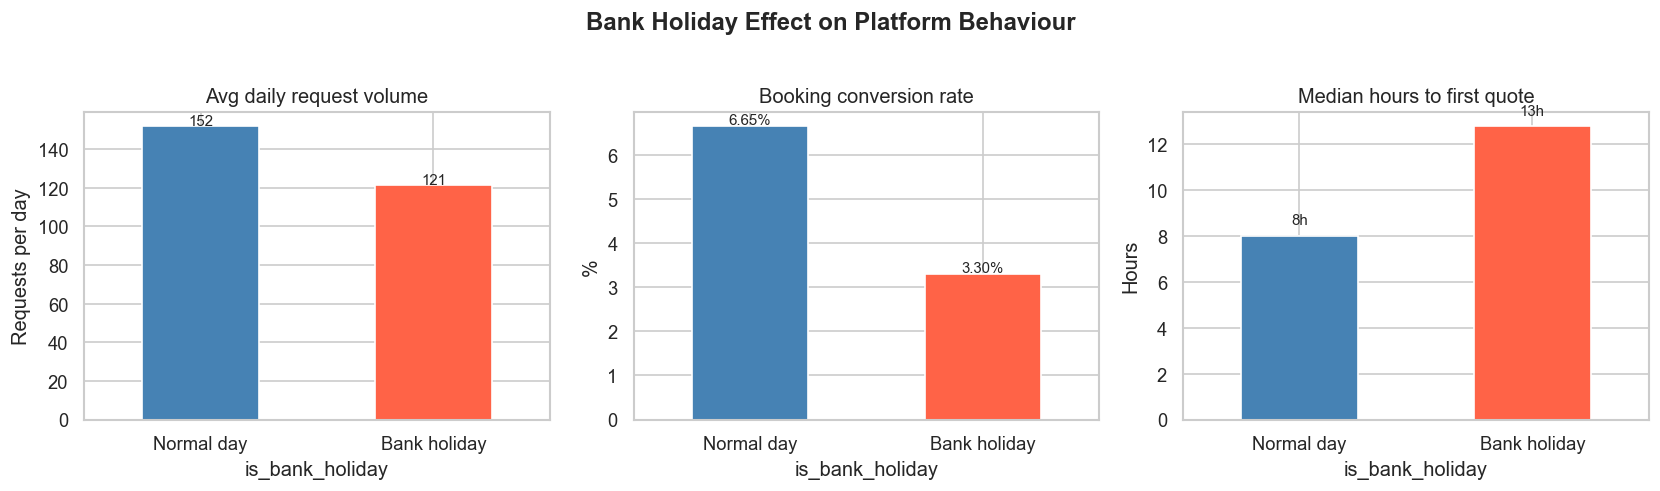

--- Conversion rate per bank holiday ---
                          n_requests booking_rate
holiday_name                                     
Easter Monday                    184        5.98%
New Year's Day                    62        4.84%
May Day                          223        3.14%
Spring Bank Holiday              227        3.08%
Good Friday                      116        1.72%
Late Summer Bank Holiday         116        1.72%
Boxing Day                        35        0.00%
Christmas Day                      7        0.00%


In [9]:
# ── Visualise the three effects ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Volume
avg_vol.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], legend=False)
axes[0].set_title('Avg daily request volume')
axes[0].set_ylabel('Requests per day')
axes[0].set_xticklabels(avg_vol.index, rotation=0)
for i, v in enumerate(avg_vol):
    axes[0].text(i, v + 0.5, f'{v:.0f}', ha='center', fontsize=9)

# 2. Conversion
conv_pct = conv * 100
conv_pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], legend=False)
axes[1].set_title('Booking conversion rate')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(conv_pct.index, rotation=0)
for i, v in enumerate(conv_pct):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

# 3. Response time
resp_summary.plot(kind='bar', ax=axes[2], color=['steelblue', 'tomato'], legend=False)
axes[2].set_title('Median hours to first quote')
axes[2].set_ylabel('Hours')
axes[2].set_xticklabels(resp_summary.index, rotation=0)
for i, v in enumerate(resp_summary):
    axes[2].text(i, v + 0.5, f'{v:.0f}h', ha='center', fontsize=9)

plt.suptitle('Bank Holiday Effect on Platform Behaviour', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES + '19_bank_holiday_effect.png', bbox_inches='tight')
plt.show()

# Per-holiday breakdown
print('--- Conversion rate per bank holiday ---')
per_hol = (
    req_level[req_level['is_bank_holiday'] == 1]
    .groupby('holiday_name')
    .agg(n_requests=('event_request_id','count'), booking_rate=('is_booked','mean'))
    .sort_values('booking_rate', ascending=False)
)
per_hol['booking_rate'] = per_hol['booking_rate'].apply(lambda x: f'{x:.2%}')
print(per_hol.to_string())

### 3.2 Day-of-Week Effect

Same three angles as above, now segmented by day of the week. Weekdays in red are weekends.

--- Avg requests per weekday ---
day_of_week
Monday       185.2
Tuesday      179.8
Wednesday    167.5
Thursday     152.6
Friday       129.7
Saturday     105.4
Sunday       135.8

--- Booking conversion (%) by weekday ---
day_of_week
Monday       7.05%
Tuesday      8.02%
Wednesday    7.94%
Thursday     7.54%
Friday       6.78%
Saturday     3.23%
Sunday       3.78%

--- Median hours to first quote by weekday ---
day_of_week
Monday        5.8
Tuesday       5.4
Wednesday     5.9
Thursday      6.5
Friday        7.8
Saturday     20.8
Sunday       15.2


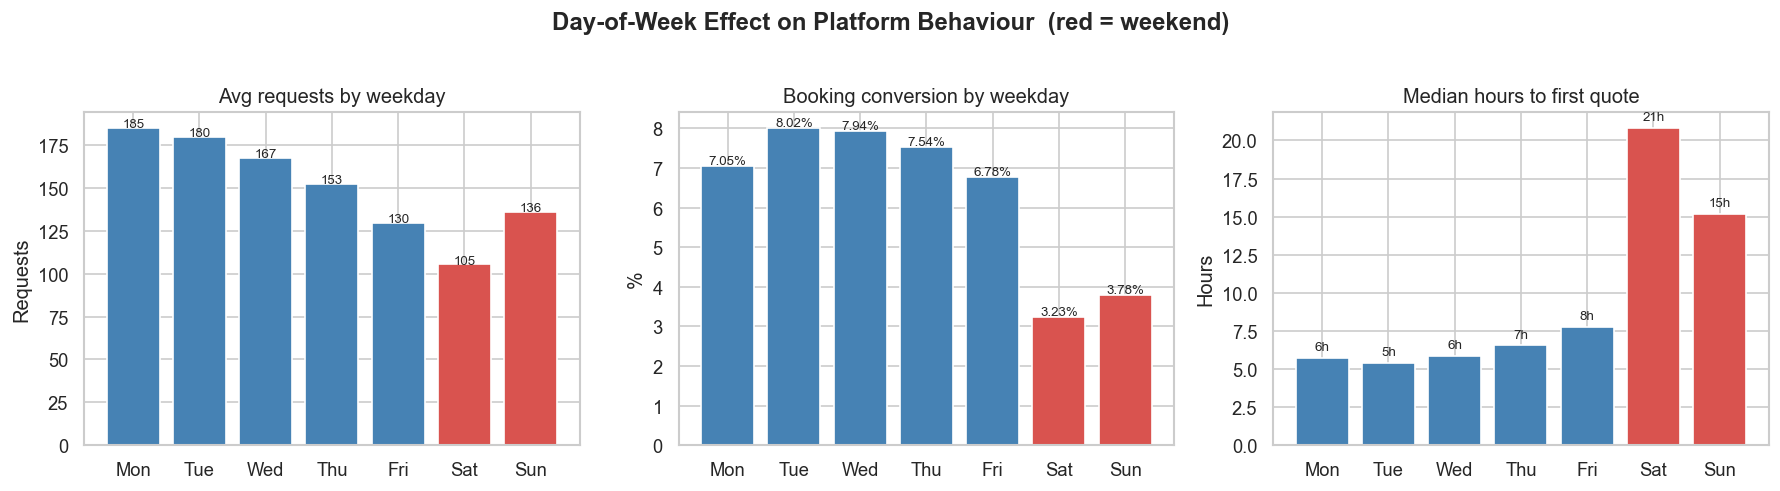

In [10]:
# ── Day-of-week analysis ─────────────────────────────────────────────────────
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 1. Request volume: average number of requests per weekday across all weeks
dow_daily = req_level.groupby(['request_date', 'day_of_week']).size().reset_index(name='n_requests')
dow_vol   = dow_daily.groupby('day_of_week')['n_requests'].mean().reindex(DOW_ORDER)

# 2. Booking conversion rate by weekday of request creation
dow_conv = req_level.groupby('day_of_week')['is_booked'].mean().reindex(DOW_ORDER) * 100

# 3. Median quote response time by weekday (uses resp df built in the bank holiday cell)
dow_resp = resp.groupby('day_of_week')['hours_to_quote'].median().reindex(DOW_ORDER)

print('--- Avg requests per weekday ---')
print(dow_vol.round(1).to_string())
print()
print('--- Booking conversion (%) by weekday ---')
print(dow_conv.apply(lambda x: f'{x:.2f}%').to_string())
print()
print('--- Median hours to first quote by weekday ---')
print(dow_resp.round(1).to_string())

# ── Visualise ─────────────────────────────────────────────────────────────────
weekend_colors = ['#d9534f' if d in ('Saturday', 'Sunday') else 'steelblue' for d in DOW_ORDER]
labels = [d[:3] for d in DOW_ORDER]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Volume
bars = axes[0].bar(labels, dow_vol, color=weekend_colors)
axes[0].set_title('Avg requests by weekday')
axes[0].set_ylabel('Requests')
for bar, v in zip(bars, dow_vol):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.0f}', ha='center', fontsize=8)

# Conversion
bars = axes[1].bar(labels, dow_conv, color=weekend_colors)
axes[1].set_title('Booking conversion by weekday')
axes[1].set_ylabel('%')
for bar, v in zip(bars, dow_conv):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.2f}%', ha='center', fontsize=8)

# Response time
bars = axes[2].bar(labels, dow_resp, color=weekend_colors)
axes[2].set_title('Median hours to first quote')
axes[2].set_ylabel('Hours')
for bar, v in zip(bars, dow_resp):
    if pd.notna(v):
        axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.0f}h', ha='center', fontsize=8)

plt.suptitle('Day-of-Week Effect on Platform Behaviour  (red = weekend)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES + '20_dow_effect.png', bbox_inches='tight')
plt.show()

### 3.3 Monthly Volume and Conversion

Does demand spike in specific months? Does conversion track with volume or move counter-cyclically?

Month  Requests  Bookings Conversion
  Jan      4486       284      6.33%
  Feb      4617       327      7.08%
  Mar      5394       346      6.41%
  Apr      5717       412      7.21%
  May      6745       417      6.18%
  Jun      6713       347      5.17%
  Jul      5420       304      5.61%
  Aug      4323       242      5.60%
  Sep      3865       278      7.19%
  Oct      3548       287      8.09%
  Nov      2691       244      9.07%
  Dec      1585       145      9.15%


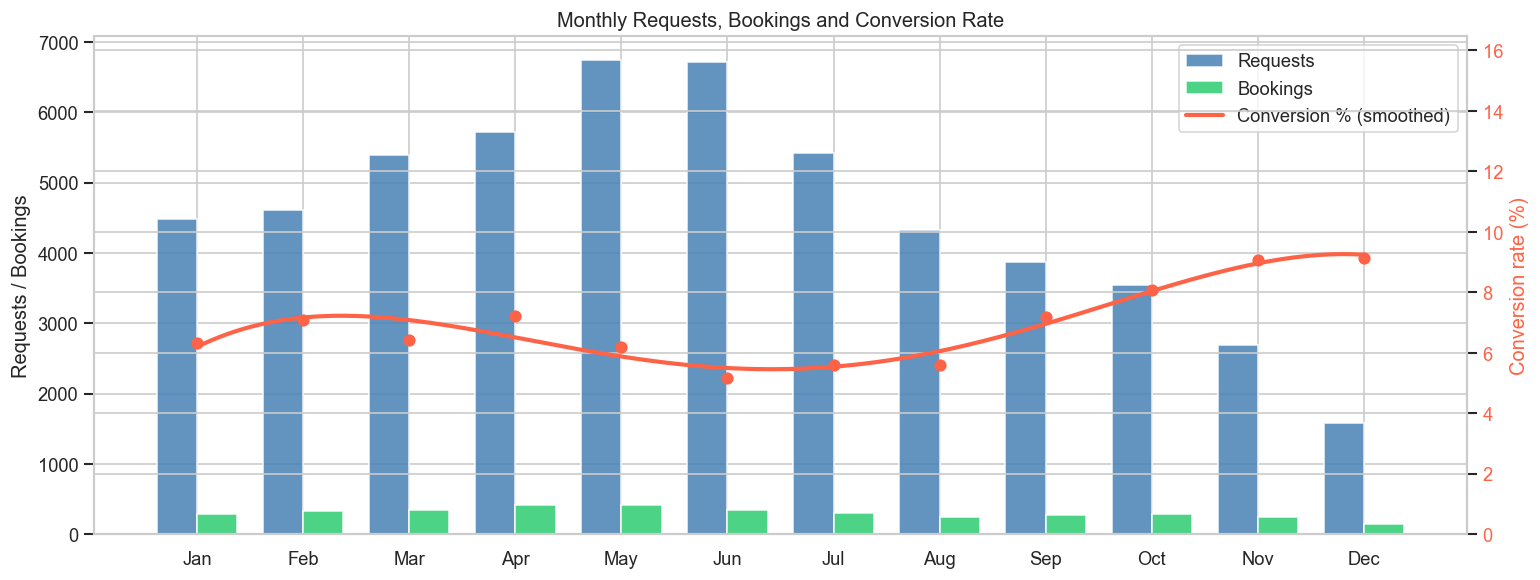

In [11]:
# ── Monthly volume and conversion ─────────────────────────────────────────────
import numpy as np

monthly = (
    req_level.groupby('month').agg(
        n_requests = ('event_request_id', 'count'),
        n_booked   = ('is_booked', 'sum'),
    ).reset_index()
)
monthly['conversion_pct'] = monthly['n_booked'] / monthly['n_requests'] * 100
monthly['month_label']    = pd.PeriodIndex(monthly['month']).strftime('%b')

# Table
table = monthly[['month_label', 'n_requests', 'n_booked', 'conversion_pct']].copy()
table.columns = ['Month', 'Requests', 'Bookings', 'Conversion']
table['Conversion'] = table['Conversion'].map('{:.2f}%'.format)
print(table.to_string(index=False))

# Chart: grouped bars (requests + bookings) + smoothed conversion line
x = np.arange(len(monthly))
w = 0.38

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(x - w/2, monthly['n_requests'], width=w, color='steelblue', label='Requests',  alpha=0.85)
ax1.bar(x + w/2, monthly['n_booked'],   width=w, color='#2ecc71',   label='Bookings',  alpha=0.85)

# Degree-4 polynomial smooth over 12 points
z        = np.polyfit(x, monthly['conversion_pct'], 4)
p        = np.poly1d(z)
x_smooth = np.linspace(0, len(monthly) - 1, 300)
ax2.plot(x_smooth, p(x_smooth), color='tomato', linewidth=2.5, label='Conversion % (smoothed)')
ax2.scatter(x, monthly['conversion_pct'], color='tomato', s=40, zorder=5)

ax1.set_xticks(x)
ax1.set_xticklabels(monthly['month_label'].tolist())
ax1.set_ylabel('Requests / Bookings')
ax2.set_ylabel('Conversion rate (%)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, monthly['conversion_pct'].max() * 1.8)
ax1.set_title('Monthly Requests, Bookings and Conversion Rate')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES + '21_monthly_distribution.png', bbox_inches='tight')
plt.show()

**Key insight — counter-cyclical pattern:** Request volume peaks in May–Jun but conversion is at its lowest (5.2–6.2%). As volume falls through Q4, conversion climbs to 9%+. This points to a supply-side bottleneck: when events demand is highest, suppliers are overloaded and cannot respond. November and December are the highest-quality months for fulfilled bookings — lower competition, higher supplier availability.

### 3.4 School Holiday Effect

Same three angles, segmented by England school holiday periods (DfE indicative dates). Key question: do families plan events differently during school holidays vs term time?

--- Request volume (avg per day) ---
is_school_holiday
Term time         154.6
School holiday    140.1
  School holidays receive 90.6% of term-time day volume

--- Booking conversion ---
is_school_holiday
Term time         6.65%
School holiday    6.42%
  Lift during school holidays: -3.5%

--- Median hours to first quote ---
is_school_holiday
Term time         7.8
School holiday    8.8

--- Per school holiday period ---
                       n_requests booking_rate
school_holiday_name                           
Autumn half-term 2024         554       10.65%
Christmas 2023/24             600        7.67%
Spring half-term 2024         786        7.51%
Easter 2024                  2865        7.09%
May half-term 2024           1242        5.80%
Summer 2024                  6184        5.69%
Christmas 2024/25             519        5.20%


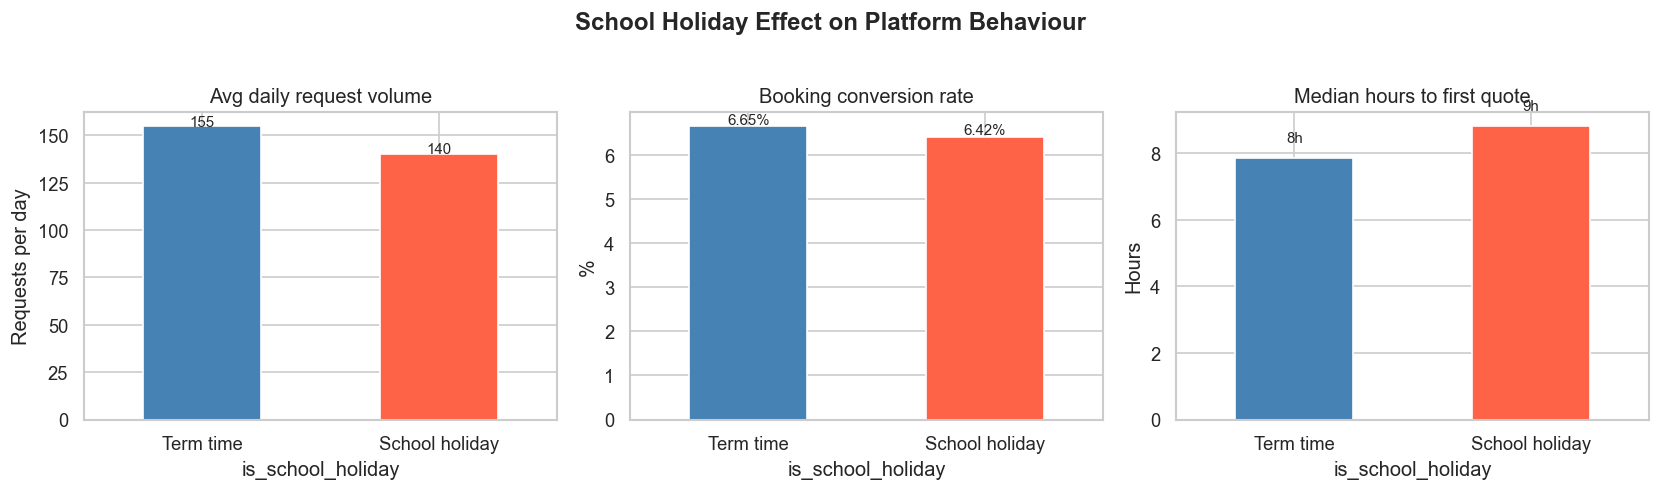

In [12]:
# ── School holiday effect ─────────────────────────────────────────────────────
avg_vol_sh = (
    req_level.groupby(['request_date', 'is_school_holiday']).size()
    .reset_index(name='n_requests')
    .groupby('is_school_holiday')['n_requests'].mean()
    .rename({0: 'Term time', 1: 'School holiday'})
)
conv_sh = (
    req_level.groupby('is_school_holiday')['is_booked'].mean()
    .rename({0: 'Term time', 1: 'School holiday'}) * 100
)
resp_sh = (
    resp.groupby('is_school_holiday')['hours_to_quote'].median()
    .rename({0: 'Term time', 1: 'School holiday'})
)

print('--- Request volume (avg per day) ---')
print(avg_vol_sh.round(1).to_string())
print(f'  School holidays receive {avg_vol_sh["School holiday"]/avg_vol_sh["Term time"]:.1%} of term-time day volume')
print()
print('--- Booking conversion ---')
print(conv_sh.apply(lambda x: f'{x:.2f}%').to_string())
lift_sh = (conv_sh['School holiday'] - conv_sh['Term time']) / conv_sh['Term time']
print(f'  Lift during school holidays: {lift_sh:+.1%}')
print()
print('--- Median hours to first quote ---')
print(resp_sh.round(1).to_string())
print()
print('--- Per school holiday period ---')
per_sh = (
    req_level[req_level['is_school_holiday'] == 1]
    .groupby('school_holiday_name')
    .agg(n_requests=('event_request_id', 'count'), booking_rate=('is_booked', 'mean'))
    .sort_values('booking_rate', ascending=False)
)
per_sh['booking_rate'] = per_sh['booking_rate'].apply(lambda x: f'{x:.2%}')
print(per_sh.to_string())

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

avg_vol_sh.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], legend=False)
axes[0].set_title('Avg daily request volume')
axes[0].set_ylabel('Requests per day')
axes[0].set_xticklabels(avg_vol_sh.index, rotation=0)
for i, v in enumerate(avg_vol_sh):
    axes[0].text(i, v + 0.5, f'{v:.0f}', ha='center', fontsize=9)

conv_sh.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], legend=False)
axes[1].set_title('Booking conversion rate')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(conv_sh.index, rotation=0)
for i, v in enumerate(conv_sh):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

resp_sh.plot(kind='bar', ax=axes[2], color=['steelblue', 'tomato'], legend=False)
axes[2].set_title('Median hours to first quote')
axes[2].set_ylabel('Hours')
axes[2].set_xticklabels(resp_sh.index, rotation=0)
for i, v in enumerate(resp_sh):
    axes[2].text(i, v + 0.5, f'{v:.0f}h', ha='center', fontsize=9)

plt.suptitle('School Holiday Effect on Platform Behaviour', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES + '22_school_holiday_effect.png', bbox_inches='tight')
plt.show()

**Key insight — school holidays are a weak signal overall, but the period breakdown matters:**
- School holidays receive 90.6% of normal term-time daily volume — almost no drop in demand.
- Overall conversion lift is only −3.5% (vs −50.4% for bank holidays), so school holidays are not a major driver of low conversion.
- **Autumn half-term** stands out with the highest conversion rate (10.65%) — high intent, low volume, suppliers available.
- **Summer** generates the most requests (6,184) but has the lowest conversion among all holiday periods (5.69%) — customers are planning events but suppliers are stretched or on holiday themselves.

---
## 4. Monthly Funnel Decomposition — why do the seasonal peaks happen?

Overall conversion = **Supply stage** (`requests → got a quote`) × **Demand/price stage** (`got a quote → booked`).
Splitting the funnel tells us whether the summer conversion dip is a **supply problem** (requests not
receiving quotes because suppliers are saturated) or a **demand/price problem** (quotes arrive but
customers don't convert). That distinction drives completely different recommendations.

Month  Requests Got quote % Booked|quote % Overall conv %
  Jan      4486       76.1%           8.3%           6.3%
  Feb      4617       71.7%           9.9%           7.1%
  Mar      5394       68.8%           9.3%           6.4%
  Apr      5717       64.8%          11.1%           7.2%
  May      6745       59.3%          10.4%           6.2%
  Jun      6713       57.9%           8.9%           5.2%
  Jul      5420       62.4%           9.0%           5.6%
  Aug      4323       70.9%           7.9%           5.6%
  Sep      3865       77.1%           9.3%           7.2%
  Oct      3548       78.6%          10.3%           8.1%
  Nov      2691       80.0%          11.3%           9.1%
  Dec      1585       85.2%          10.7%           9.1%


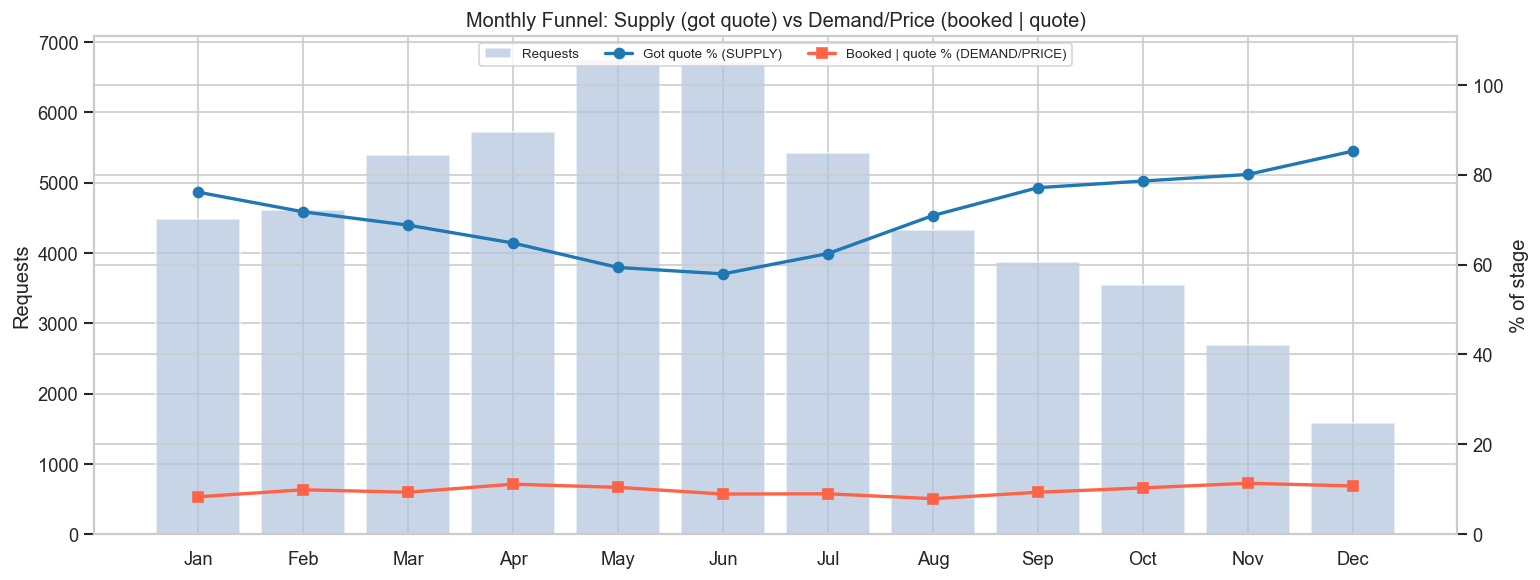

In [13]:
# ── Monthly funnel: split conversion into a SUPPLY stage and a DEMAND/PRICE stage ──
# Stage 1 (supply):        requests -> got >=1 quote     = % of requests that suppliers responded to
# Stage 2 (demand/price):  got quote -> booked           = of those quoted, % that converted
# Overall conversion = Stage 1 x Stage 2
funnel = (
    req_level.assign(got_quote=(req_level['n_quotes'] > 0).astype(int))
    .groupby('month').agg(
        requests   = ('event_request_id', 'count'),
        got_quote  = ('got_quote', 'sum'),
        booked     = ('is_booked', 'sum'),
    ).reset_index()
)
funnel['pct_got_quote']        = funnel['got_quote'] / funnel['requests'] * 100   # supply
funnel['pct_booked_of_quoted'] = funnel['booked']    / funnel['got_quote'] * 100  # demand/price
funnel['overall_conversion']   = funnel['booked']    / funnel['requests'] * 100
funnel['month_label']          = pd.PeriodIndex(funnel['month']).strftime('%b')

show = funnel[['month_label', 'requests', 'pct_got_quote', 'pct_booked_of_quoted', 'overall_conversion']].copy()
show.columns = ['Month', 'Requests', 'Got quote %', 'Booked|quote %', 'Overall conv %']
for c in ['Got quote %', 'Booked|quote %', 'Overall conv %']:
    show[c] = show[c].map('{:.1f}%'.format)
print(show.to_string(index=False))

# Chart: request volume (bars) + the two funnel stages (lines)
import numpy as np
x = np.arange(len(funnel))
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(x, funnel['requests'], color='lightsteelblue', label='Requests', alpha=0.7)
ax2.plot(x, funnel['pct_got_quote'],        color='#1f77b4', marker='o', lw=2, label='Got quote % (SUPPLY)')
ax2.plot(x, funnel['pct_booked_of_quoted'], color='tomato',  marker='s', lw=2, label='Booked | quote % (DEMAND/PRICE)')

ax1.set_xticks(x); ax1.set_xticklabels(funnel['month_label'])
ax1.set_ylabel('Requests')
ax2.set_ylabel('% of stage')
ax2.set_ylim(0, max(funnel['pct_got_quote'].max(), funnel['pct_booked_of_quoted'].max()) * 1.3)
ax1.set_title('Monthly Funnel: Supply (got quote) vs Demand/Price (booked | quote)')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper center', ncol=3, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES + '23_monthly_funnel.png', bbox_inches='tight')
plt.show()

**Key insight — the seasonal dip is a SUPPLY bottleneck, not weaker demand.** The *demand/price* stage
(`booked | quote`) is fairly flat all year (~8–11%). What collapses in peak season is the *supply*
stage: only **58–62%** of requests get a quote in May–Jul, versus **80–85%** in Nov–Dec. When demand is
highest, suppliers are most stretched and the most requests go **unquoted** — that is where bookings (and
revenue) leak. The lever is **supplier capacity in peak months**, not demand generation.

---
## 5. Price vs Budget Post-Mortem — booked vs not-booked

The single most important commercial question: **does price drive conversion?** We compare each quote's
price to the customer's stated budget (`price_to_budget = quote_price / request_budget`) and ask:
1. Does conversion collapse when quotes come in **over budget**?
2. Do **booked** quotes price differently from **lost** ones?
3. When several suppliers compete for the same request, **does the cheapest win?**

--- Conversion by price/budget bucket (quote-level) ---
                         n_quotes booking_rate
pb_bucket                                     
<0.8 (under)                51664        2.30%
0.8-1.0 (at/under)          42467        2.14%
1.0-1.2 (slightly over)     56528        2.14%
>1.2 (well over)            67662        1.38%

--- Booked vs not-booked quotes ---
           median_price median_price_to_budget       n
booked                                                
Not booked       £1,487                  1.02x  214090
Booked           £1,155                  1.00x    4239



--- Within-request competition (3,976 bookings with >1 competing quote) ---
  Bookings that went to the CHEAPEST quote: 29.7%
  Median normalised price rank of the winner (0=cheapest, 1=dearest): 0.29


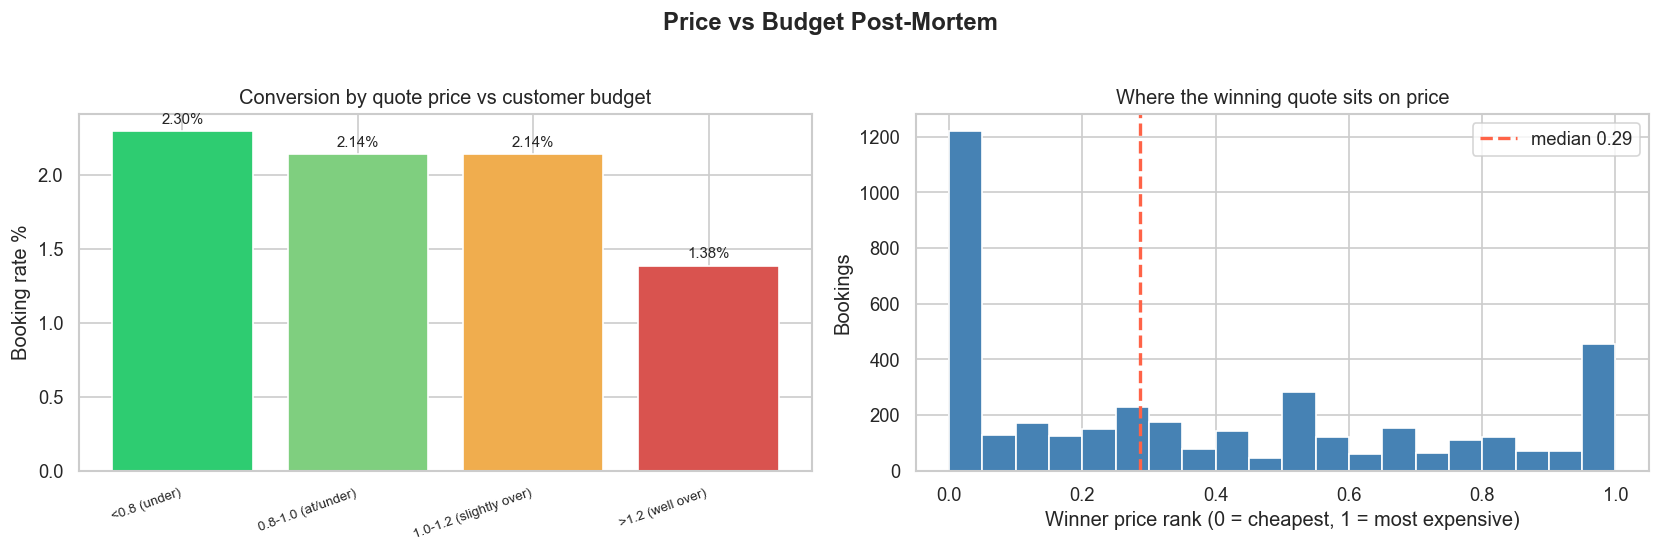

In [14]:
# ── Price vs Budget post-mortem (quote-level) ─────────────────────────────────
q = df[df['has_quote']].copy()
q = q[(q['request_budget'] > 0) & q['quote_price'].notna()]
q['price_to_budget'] = q['quote_price'] / q['request_budget']

# 1) Conversion rate by price/budget bucket -----------------------------------
bins   = [0, 0.8, 1.0, 1.2, np.inf]
labels = ['<0.8 (under)', '0.8-1.0 (at/under)', '1.0-1.2 (slightly over)', '>1.2 (well over)']
q['pb_bucket'] = pd.cut(q['price_to_budget'], bins=bins, labels=labels)

bucket = q.groupby('pb_bucket', observed=True).agg(
    n_quotes     = ('quote_id', 'count'),
    booking_rate = ('booked', 'mean'),
)
bucket['booking_rate_pct'] = bucket['booking_rate'] * 100
print('--- Conversion by price/budget bucket (quote-level) ---')
print(bucket.assign(booking_rate=lambda d: d['booking_rate_pct'].map('{:.2f}%'.format))
            [['n_quotes', 'booking_rate']].to_string())

# 2) Booked vs not-booked: price and price/budget -----------------------------
cmp = q.groupby('booked').agg(
    median_price          = ('quote_price', 'median'),
    median_price_to_budget= ('price_to_budget', 'median'),
    n                     = ('quote_id', 'count'),
).rename(index={0: 'Not booked', 1: 'Booked'})
print('\n--- Booked vs not-booked quotes ---')
print(cmp.assign(
    median_price=lambda d: d['median_price'].map('£{:,.0f}'.format),
    median_price_to_budget=lambda d: d['median_price_to_budget'].map('{:.2f}x'.format),
).to_string())

# 3) Within-request price rank: does the cheapest quote win? -------------------
q['price_rank']  = q.groupby('event_request_id')['quote_price'].rank(method='min')
q['n_competing'] = q.groupby('event_request_id')['quote_id'].transform('count')
multi = q[q['n_competing'] > 1]
booked_multi = multi[multi['booked'] == 1].copy()
# normalised rank: 0 = cheapest, 1 = most expensive among competing quotes
booked_multi['norm_rank'] = (booked_multi['price_rank'] - 1) / (booked_multi['n_competing'] - 1)
pct_cheapest = (booked_multi['price_rank'] == 1).mean() * 100
print(f'\n--- Within-request competition ({len(booked_multi):,} bookings with >1 competing quote) ---')
print(f'  Bookings that went to the CHEAPEST quote: {pct_cheapest:.1f}%')
print(f'  Median normalised price rank of the winner (0=cheapest, 1=dearest): {booked_multi["norm_rank"].median():.2f}')

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

colors = ['#2ecc71', '#7fcf7f', '#f0ad4e', '#d9534f']
axes[0].bar(range(len(bucket)), bucket['booking_rate_pct'], color=colors)
axes[0].set_xticks(range(len(bucket)))
axes[0].set_xticklabels(bucket.index, rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Booking rate %')
axes[0].set_title('Conversion by quote price vs customer budget')
for i, v in enumerate(bucket['booking_rate_pct']):
    axes[0].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

axes[1].hist(booked_multi['norm_rank'], bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(booked_multi['norm_rank'].median(), color='tomato', ls='--', lw=2,
                label=f'median {booked_multi["norm_rank"].median():.2f}')
axes[1].set_xlabel('Winner price rank (0 = cheapest, 1 = most expensive)')
axes[1].set_ylabel('Bookings')
axes[1].set_title('Where the winning quote sits on price')
axes[1].legend()

plt.suptitle('Price vs Budget Post-Mortem', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES + '24_price_vs_budget_postmortem.png', bbox_inches='tight')
plt.show()

**Key insight — price matters, but it isn't the whole story.** Quotes priced **well over budget (>1.2×)**
convert at **1.38%**, ~35% worse than quotes at/under budget (**2.14–2.30%**). Booked quotes are cheaper
(median **£1,155 vs £1,487**) and sit right at budget (**1.00× vs 1.02×**). Yet only **29.7%** of
competitive bookings go to the absolute cheapest quote (the median winner sits at the **29th percentile**
on price) — customers reward *competitive pricing within budget*, not rock-bottom. **Lever:** coach
suppliers to quote within budget; pricing >20% over budget is where deals die.

---
## 6. Ticket & GMV per Booking — the £ dimension

Conversion counts tell us *how often* we win; the **ticket** (price of a booked quote) tells us *how
much each win is worth*. A category with mediocre conversion but a high ticket can still be the biggest
prize.

> **Terminology:** "revenue" in this section means **GMV — Gross Booking Value** = the `quote_price` the
> customer pays the supplier on a booked quote. **Togather's own revenue is a commission (a % cut) of
> GMV** (rate not in the data). So read these £ as *booking value flowing through the platform*;
> Togather's take is a fixed fraction of it, and the **relative** sizing across segments is unaffected.

--- Booked GMV 2024 (quote_price where booked == 1) ---
  Bookings (booked quotes): 4,239
  Total booked GMV:         £6,332,402   (Togather revenue = commission % of this)
  Avg ticket:               £1,494   |   Median ticket: £1,155

--- GMV by macro category (customer side) ---
                  bookings         gmv avg_ticket
customer_macro                                   
Street Food           1195  £1,615,938     £1,352
World & Fusion         586    £793,946     £1,355
BBQ & Meats            538    £786,893     £1,463
European               426    £663,418     £1,557
Sharing & Events       314    £638,931     £2,035
Asian & Indian         389    £560,387     £1,441
Sweet & Desserts       250    £349,980     £1,400
Dietary                 68    £112,219     £1,650
Bar & Drinks             1      £1,512     £1,512

--- GMV by region ---
                 bookings         gmv avg_ticket
region                                          
Greater London       1720  £2,726,642     £1,5

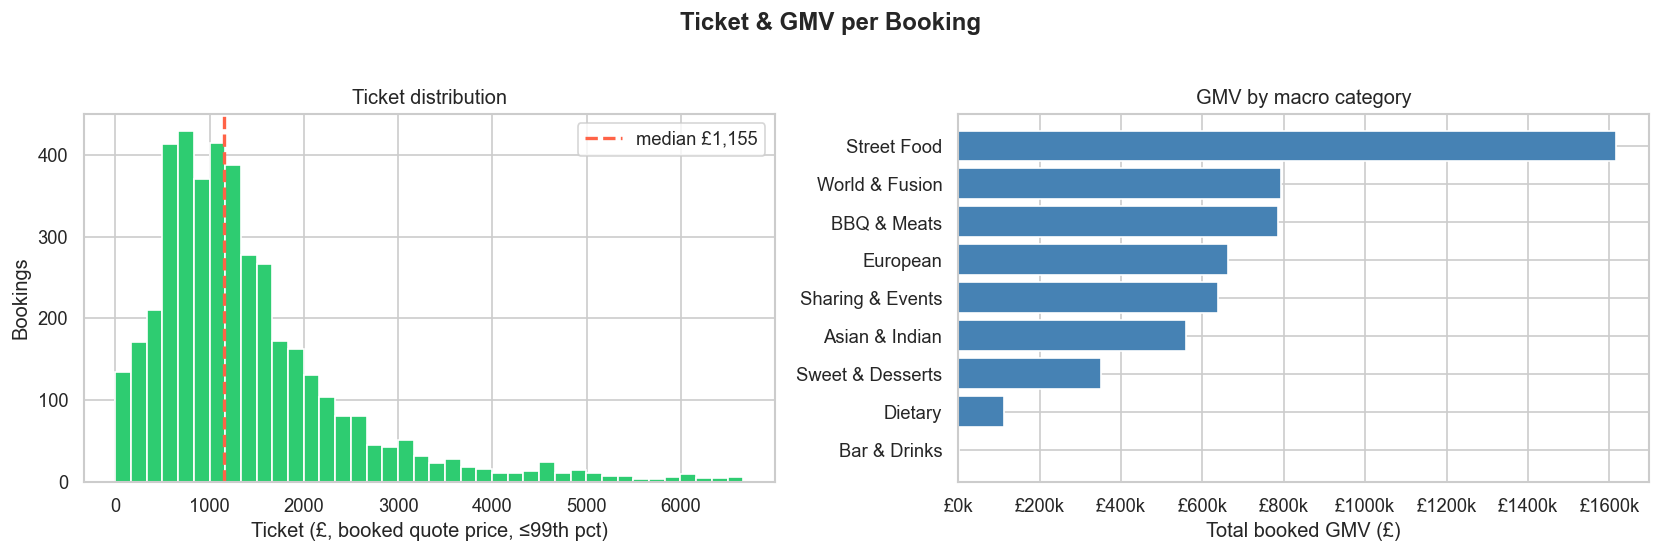

In [15]:
# ── Ticket / GMV per booking ──────────────────────────────────────────────────
# ticket = price of a booked quote. GMV (gross booking value) is attributed to the REQUEST's
# category/region (customer_macro) so it lines up with the request-level conversion analysis.
# NOTE: GMV is what the customer pays the supplier; Togather's revenue is a commission % of this.
booked_q = df[df['booked'] == 1].copy()
booked_q = booked_q[booked_q['quote_price'].notna()]

total_gmv  = booked_q['quote_price'].sum()
n_bookings = len(booked_q)
avg_ticket = booked_q['quote_price'].mean()
med_ticket = booked_q['quote_price'].median()

print('--- Booked GMV 2024 (quote_price where booked == 1) ---')
print(f'  Bookings (booked quotes): {n_bookings:,}')
print(f'  Total booked GMV:         £{total_gmv:,.0f}   (Togather revenue = commission % of this)')
print(f'  Avg ticket:               £{avg_ticket:,.0f}   |   Median ticket: £{med_ticket:,.0f}')

# By macro category
by_macro = booked_q.groupby('customer_macro').agg(
    bookings = ('quote_id', 'count'),
    gmv      = ('quote_price', 'sum'),
    avg_ticket = ('quote_price', 'mean'),
).sort_values('gmv', ascending=False)
print('\n--- GMV by macro category (customer side) ---')
print(by_macro.assign(
    gmv=lambda d: d['gmv'].map('£{:,.0f}'.format),
    avg_ticket=lambda d: d['avg_ticket'].map('£{:,.0f}'.format),
).to_string())

# By region
by_region = booked_q.groupby('region').agg(
    bookings = ('quote_id', 'count'),
    gmv      = ('quote_price', 'sum'),
    avg_ticket = ('quote_price', 'mean'),
).sort_values('gmv', ascending=False)
print('\n--- GMV by region ---')
print(by_region.assign(
    gmv=lambda d: d['gmv'].map('£{:,.0f}'.format),
    avg_ticket=lambda d: d['avg_ticket'].map('£{:,.0f}'.format),
).to_string())

# By month
by_month = booked_q.groupby('month').agg(
    bookings = ('quote_id', 'count'),
    gmv      = ('quote_price', 'sum'),
).reset_index()
by_month['month_label'] = pd.PeriodIndex(by_month['month']).strftime('%b')

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

cap = booked_q['quote_price'].quantile(0.99)
axes[0].hist(booked_q.loc[booked_q['quote_price'] <= cap, 'quote_price'], bins=40,
             color='#2ecc71', edgecolor='white')
axes[0].axvline(med_ticket, color='tomato', ls='--', lw=2, label=f'median £{med_ticket:,.0f}')
axes[0].set_xlabel('Ticket (£, booked quote price, ≤99th pct)')
axes[0].set_ylabel('Bookings')
axes[0].set_title('Ticket distribution')
axes[0].legend()

axes[1].barh(by_macro.index[::-1], by_macro['gmv'].values[::-1], color='steelblue')
axes[1].set_xlabel('Total booked GMV (£)')
axes[1].set_title('GMV by macro category')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v/1000:.0f}k'))

plt.suptitle('Ticket & GMV per Booking', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES + '25_ticket_revenue.png', bbox_inches='tight')
plt.show()

**Key insight — GMV concentration.** 2024 booked **GMV is £6.33M** across 4,239 bookings (avg ticket
**£1,494**, median £1,155) — Togather's own revenue is a commission % of this. **Street Food** leads GMV
on sheer volume (£1.6M), while **Sharing & Events** carries the highest ticket (~£2k+). **Greater London
alone is £2.73M — 43% of all GMV.** Volume, conversion and ticket each point at a different segment, so
the next section combines all three.

---
## 7. Segment Conversion Table & Opportunity Sizing

We now combine the three levers — **volume** (requests), **conversion**, and **ticket** (£) — into one
view per segment. A "segment" is primarily one of the **10 macro categories**, with region and
macro×region cross-cuts. Section 7a is the segment table (also the input to the 2025 forecast cascade);
7b sizes the **£ upside** of lifting laggard segments to a benchmark conversion.

In [16]:
# ── Segment conversion table (this same table feeds the forecast cascade) ─────
# GMV = gross booking value (sum of booked quote prices). Togather revenue = commission % of GMV.
req_gmv = booked_q.groupby('event_request_id')['quote_price'].sum()
req_level['gmv'] = req_level['event_request_id'].map(req_gmv).fillna(0.0)

def segment_table(frame, by):
    g = frame.groupby(by).agg(
        requests = ('event_request_id', 'count'),
        bookings = ('is_booked', 'sum'),
        gmv      = ('gmv', 'sum'),
    )
    g['conversion'] = g['bookings'] / g['requests']
    g['avg_ticket'] = g['gmv'] / g['bookings'].replace(0, np.nan)
    return g.sort_values('gmv', ascending=False)

def fmt_seg(g):
    return g.assign(
        conversion = lambda d: d['conversion'].map('{:.2%}'.format),
        avg_ticket = lambda d: d['avg_ticket'].map('£{:,.0f}'.format),
        gmv        = lambda d: d['gmv'].map('£{:,.0f}'.format),
    )[['requests', 'bookings', 'conversion', 'avg_ticket', 'gmv']]

seg_macro  = segment_table(req_level, 'customer_macro')
seg_region = segment_table(req_level, 'region')

print('=== Segment conversion + GMV — by MACRO CATEGORY ===')
print(fmt_seg(seg_macro).to_string())
print('\n=== Segment conversion + GMV — by REGION ===')
print(fmt_seg(seg_region).to_string())

# Top macro x region cells by GMV
req_level['macro_region'] = (req_level['customer_macro'].astype(str)
                             + '  |  ' + req_level['region'].astype(str))
seg_cross = segment_table(req_level, 'macro_region').head(15)
print('\n=== Top 15 macro x region cells by GMV ===')
print(fmt_seg(seg_cross).to_string())

=== Segment conversion + GMV — by MACRO CATEGORY ===
                  requests  bookings conversion avg_ticket         gmv
customer_macro                                                        
Street Food          13259      1029      7.76%     £1,570  £1,615,938
World & Fusion        5896       490      8.31%     £1,620    £793,946
BBQ & Meats           9174       464      5.06%     £1,696    £786,893
European              6496       381      5.87%     £1,741    £663,418
Sharing & Events      3255       262      8.05%     £2,439    £638,931
Asian & Indian        5421       301      5.55%     £1,862    £560,387
Sweet & Desserts      3773       226      5.99%     £1,549    £349,980
Dietary                895        55      6.15%     £2,040    £112,219
Bar & Drinks             6         1     16.67%     £1,512      £1,512
Service                  4         0      0.00%       £nan          £0

=== Segment conversion + GMV — by REGION ===
                  requests  bookings conversion a

Benchmark conversion (top-quartile segment): 7.98%
Total addressable GMV upside if laggards reach benchmark: £1,132,360
  (Togather revenue impact = commission % of this GMV upside)

--- Opportunity sizing by macro category ---
                  requests conversion avg_ticket upside_bookings upside_gmv
customer_macro                                                             
BBQ & Meats           9174      5.06%     £1,696             268   £454,185
Asian & Indian        5421      5.55%     £1,862             131   £244,701
European              6496      5.87%     £1,741             137   £238,882
Sweet & Desserts      3773      5.99%     £1,549              75   £116,104
Street Food          13259      7.76%     £1,570              29    £45,036
Dietary                895      6.15%     £2,040              16    £33,451
World & Fusion        5896      8.31%     £1,620               0         £0
Sharing & Events      3255      8.05%     £2,439               0         £0
Bar & Drinks

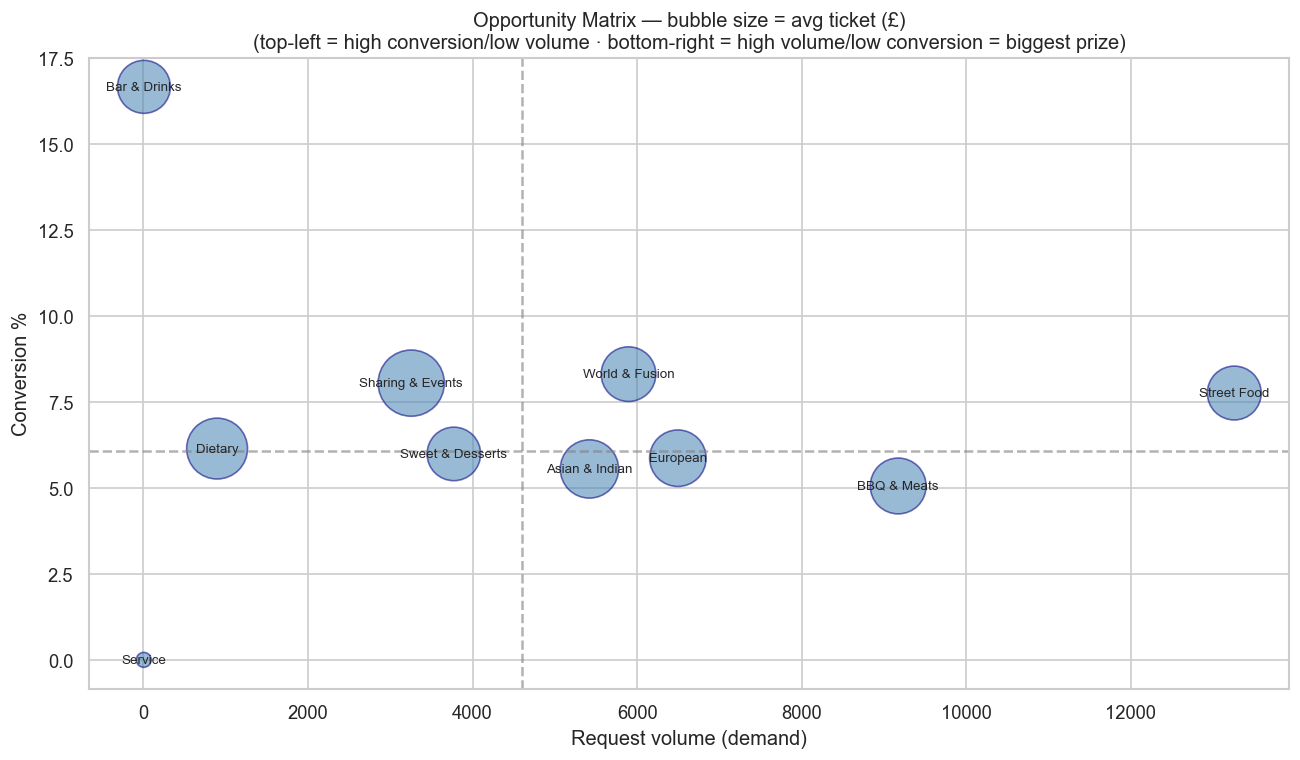

In [17]:
# ── Opportunity sizing: lift laggard segments to a benchmark conversion ───────
opp = seg_macro.copy()
opp['avg_ticket'] = opp['avg_ticket'].fillna(0.0)
benchmark = opp['conversion'].quantile(0.75)   # top-quartile segment conversion as the target
opp['upside_bookings'] = (benchmark - opp['conversion']).clip(lower=0) * opp['requests']
opp['upside_gmv']      = opp['upside_bookings'] * opp['avg_ticket']
opp_sorted = opp.sort_values('upside_gmv', ascending=False)

print(f'Benchmark conversion (top-quartile segment): {benchmark:.2%}')
print(f'Total addressable GMV upside if laggards reach benchmark: £{opp["upside_gmv"].sum():,.0f}')
print('  (Togather revenue impact = commission % of this GMV upside)')
print('\n--- Opportunity sizing by macro category ---')
print(opp_sorted.assign(
    conversion     = lambda d: d['conversion'].map('{:.2%}'.format),
    avg_ticket     = lambda d: d['avg_ticket'].map('£{:,.0f}'.format),
    upside_bookings= lambda d: d['upside_bookings'].map('{:,.0f}'.format),
    upside_gmv     = lambda d: d['upside_gmv'].map('£{:,.0f}'.format),
)[['requests', 'conversion', 'avg_ticket', 'upside_bookings', 'upside_gmv']].to_string())

# Bubble chart: volume vs conversion, bubble size = avg ticket
fig, ax = plt.subplots(figsize=(11, 6.5))
sizes = (opp['avg_ticket'] / opp['avg_ticket'].max() * 1500) + 80
ax.scatter(opp['requests'], opp['conversion'] * 100, s=sizes, alpha=0.55,
           color='steelblue', edgecolor='navy')
for name, r in opp.iterrows():
    ax.annotate(name, (r['requests'], r['conversion'] * 100), fontsize=8, ha='center', va='center')
ax.axvline(opp['requests'].median(), color='grey', ls='--', alpha=0.6)
ax.axhline(opp['conversion'].median() * 100, color='grey', ls='--', alpha=0.6)
ax.set_xlabel('Request volume (demand)')
ax.set_ylabel('Conversion %')
ax.set_title('Opportunity Matrix — bubble size = avg ticket (£)\n(top-left = high conversion/low volume · bottom-right = high volume/low conversion = biggest prize)')
plt.tight_layout()
plt.savefig(FIGURES + '26_opportunity_matrix.png', bbox_inches='tight')
plt.show()

**Key insight — where the 2025 prize is.** Lifting laggard categories to the top-quartile conversion
(**7.98%**) is worth **~£1.13M** of addressable **GMV** (Togather's cut is a % of that). The single
biggest prize is **BBQ & Meats (£454k)** — high volume (9,174 requests), high ticket (£1,696), but weak
conversion (5.06%); then **Asian & Indian (£245k)** and **European (£239k)**. Regionally, conversion runs
from **Greater London 12.0%** down to **South West 3.8%** — a ~3× gap that is itself a supply-coverage
opportunity. (Bar & Drinks and Service are immaterial: <10 requests each.)

---
## 8. Decision Trees — what moves the needle on bookings

Two complementary models (shallow trees, `max_depth=4`, class-balanced because bookings are rare):
- **8a Request-level** (`is_booked`): what makes a whole request convert — coverage, budget, price
  competitiveness, locality, category, seasonality.
- **8b Quote-level** (`booked`): given a quote exists, what makes *that quote* win — price vs budget,
  locality, response speed, competition.

> **Caveat:** `n_quotes` / `n_competing_quotes` are *downstream of supply* (you don't know them before the
> request is worked). Read them as "coverage/competition matters," not as a pre-request predictor.
> Feature importances are directional, not causal.

--- Request-level tree: top feature importances (drivers of is_booked) ---
n_quotes                  0.894816
min_price_to_budget       0.043781
request_budget            0.026374
is_weekend                0.020768
region_Greater London     0.012336
month_num                 0.001924
has_quote                 0.000000
has_local_supplier        0.000000
is_bank_holiday           0.000000
is_school_holiday         0.000000
region_East Midlands      0.000000
region_East of England    0.000000


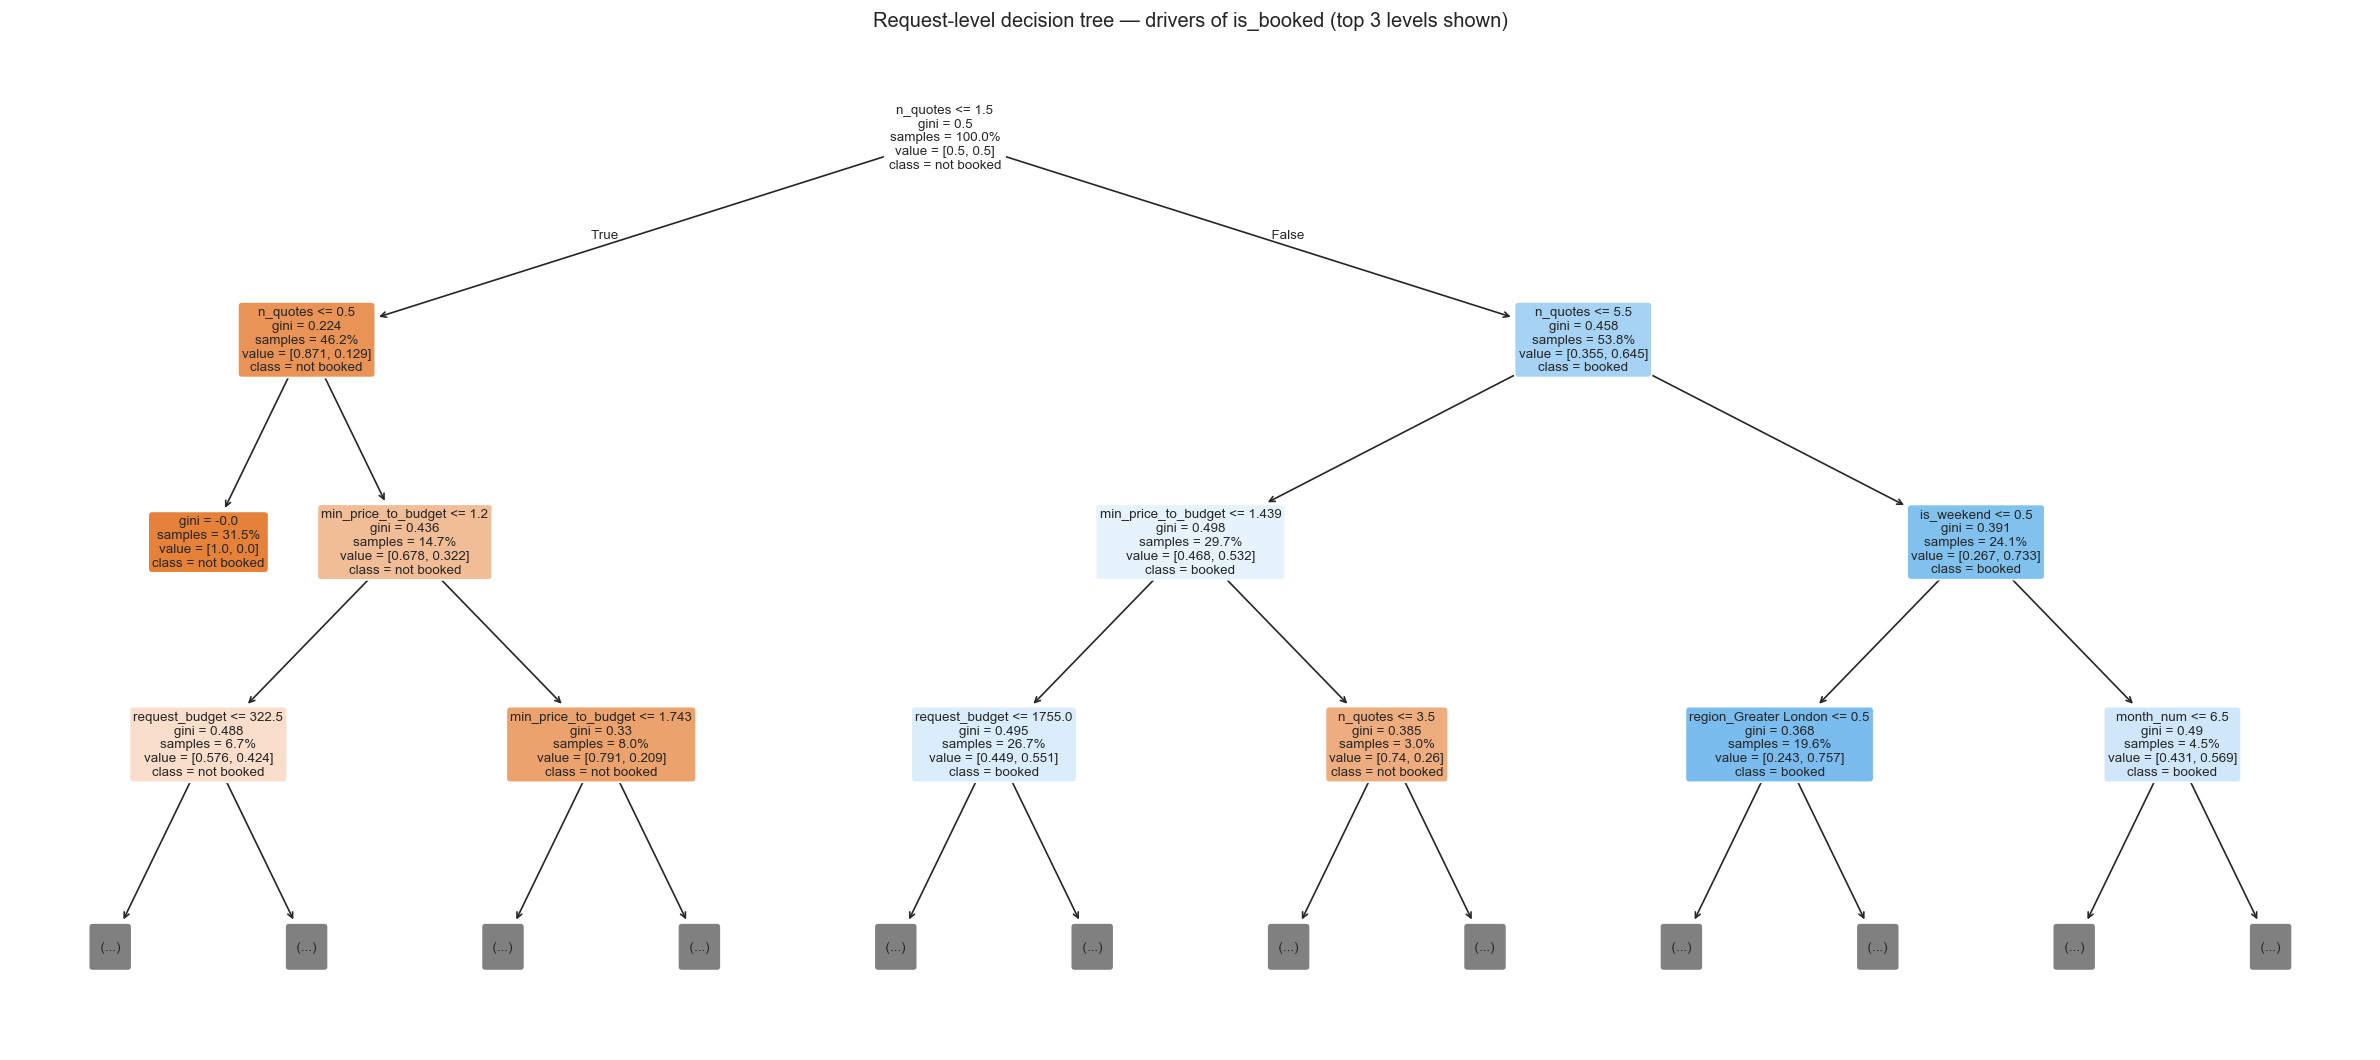

In [18]:
# ── 8a. Request-level tree: what makes a request CONVERT (is_booked)? ──────────
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Engineer request-level price/locality features from the quote-level data
q_all = df[df['has_quote']].copy()
q_all = q_all[q_all['request_budget'] > 0]
q_all['ptb'] = q_all['quote_price'] / q_all['request_budget']
min_ptb = q_all.groupby('event_request_id')['ptb'].min()
local   = (q_all['supplier_region'] == q_all['region']).groupby(q_all['event_request_id']).max()

rl = req_level.copy()
rl['min_price_to_budget'] = rl['event_request_id'].map(min_ptb)
rl['has_local_supplier']  = rl['event_request_id'].map(local).fillna(False).astype(int)
rl['has_quote']           = (rl['n_quotes'] > 0).astype(int)
rl['month_num']           = rl['created'].dt.month
# requests with no quote have no price ratio; has_quote already separates them, so median-fill is neutral
rl['min_price_to_budget'] = rl['min_price_to_budget'].fillna(rl['min_price_to_budget'].median())

num_feats = ['request_budget', 'n_quotes', 'min_price_to_budget', 'has_local_supplier',
             'has_quote', 'month_num', 'is_bank_holiday', 'is_weekend', 'is_school_holiday']
cat_feats = ['region', 'customer_macro']
X = pd.concat([
    rl[num_feats],
    pd.get_dummies(rl[cat_feats].fillna('Unknown'), prefix=cat_feats),
], axis=1)
y = rl['is_booked']

clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=200,
                             class_weight='balanced', random_state=42)
clf.fit(X, y)

imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print('--- Request-level tree: top feature importances (drivers of is_booked) ---')
print(imp.head(12).to_string())

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(clf, feature_names=list(X.columns), class_names=['not booked', 'booked'],
          filled=True, rounded=True, max_depth=3, fontsize=8, ax=ax, proportion=True)
ax.set_title('Request-level decision tree — drivers of is_booked (top 3 levels shown)')
plt.tight_layout()
plt.savefig(FIGURES + '27_tree_request_level.png', bbox_inches='tight')
plt.show()

--- Quote-level tree: top feature importances (drivers of a quote being booked) ---
quote_price                  0.498544
macro_match                  0.198009
hours_to_quote               0.161044
price_to_budget              0.077132
supmacro_Street Food         0.023490
n_competing_quotes           0.021381
supmacro_Sweet & Desserts    0.020399
is_local                     0.000000
supmacro_Asian & Indian      0.000000
supmacro_Bar & Drinks        0.000000
supmacro_BBQ & Meats         0.000000
supmacro_Dietary             0.000000


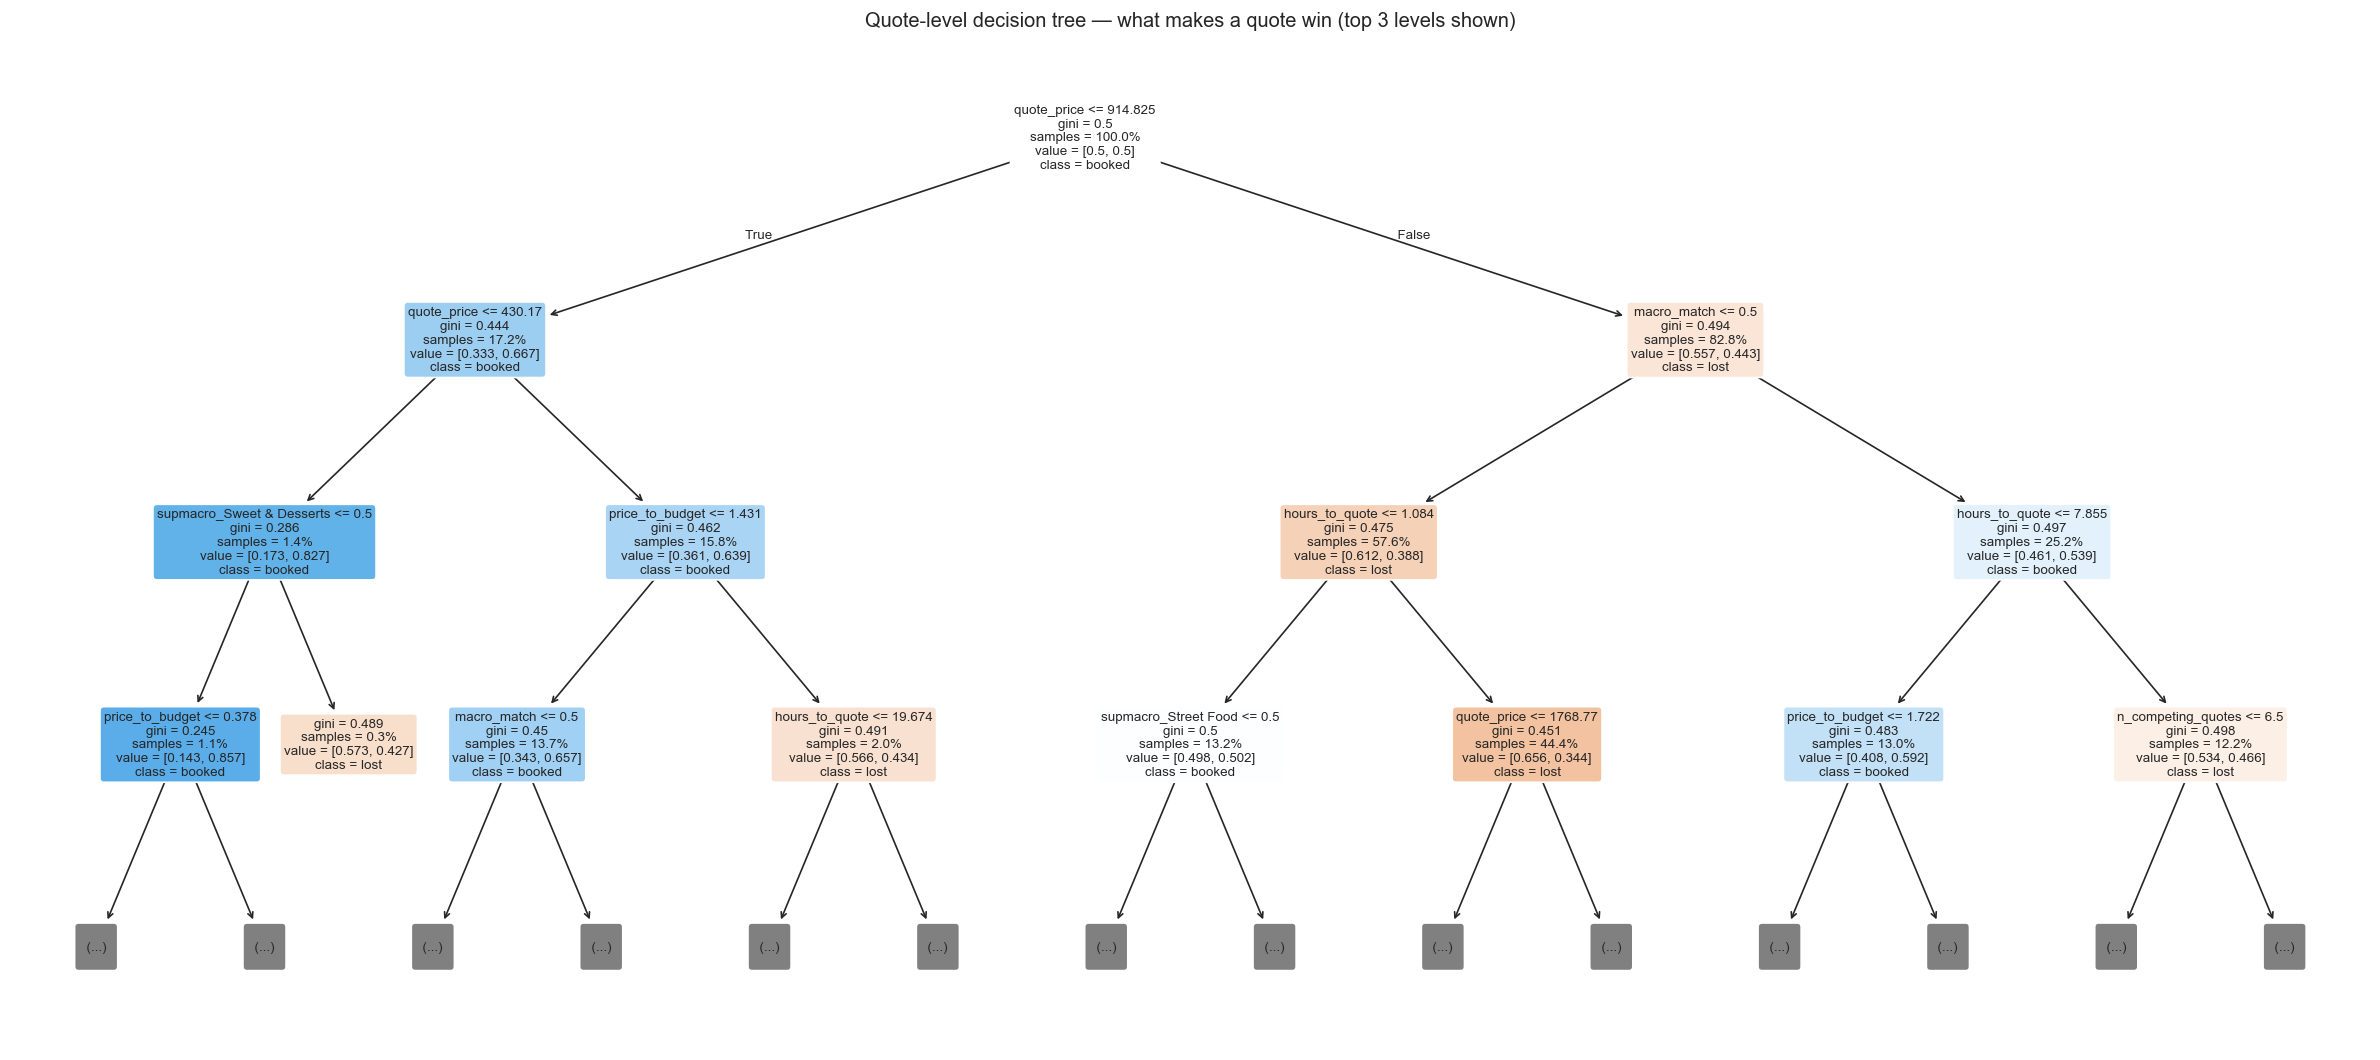

In [19]:
# ── 8b. Quote-level tree: given a quote exists, what makes it WIN? ─────────────
qq = df[df['has_quote']].copy()
qq = qq[(qq['request_budget'] > 0) & qq['quote_price'].notna()]
qq['price_to_budget']    = qq['quote_price'] / qq['request_budget']
qq['is_local']           = (qq['supplier_region'] == qq['region']).astype(int)
qq['hours_to_quote']     = (qq['quote_created'] - qq['created']).dt.total_seconds() / 3600
qq = qq[(qq['hours_to_quote'] >= 0) & (qq['hours_to_quote'] <= 720)]
qq['n_competing_quotes'] = qq.groupby('event_request_id')['quote_id'].transform('count')
qq['macro_match']        = (qq['supplier_macro'] == qq['customer_macro']).astype(int)

num_feats2 = ['quote_price', 'price_to_budget', 'is_local', 'hours_to_quote',
              'n_competing_quotes', 'macro_match']
X2 = pd.concat([
    qq[num_feats2],
    pd.get_dummies(qq['supplier_macro'].fillna('Unknown'), prefix='supmacro'),
], axis=1)
y2 = qq['booked']

clf2 = DecisionTreeClassifier(max_depth=4, min_samples_leaf=500,
                              class_weight='balanced', random_state=42)
clf2.fit(X2, y2)

imp2 = pd.Series(clf2.feature_importances_, index=X2.columns).sort_values(ascending=False)
print('--- Quote-level tree: top feature importances (drivers of a quote being booked) ---')
print(imp2.head(12).to_string())

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(clf2, feature_names=list(X2.columns), class_names=['lost', 'booked'],
          filled=True, rounded=True, max_depth=3, fontsize=8, ax=ax, proportion=True)
ax.set_title('Quote-level decision tree — what makes a quote win (top 3 levels shown)')
plt.tight_layout()
plt.savefig(FIGURES + '28_tree_quote_level.png', bbox_inches='tight')
plt.show()

**Key insight — the two trees agree and complement each other.** *Request-level:* **`n_quotes` dominates
(importance 0.89)** — coverage is the #1 driver of whether a request converts, far ahead of price (0.04)
and budget (0.03). The supply story again, quantified. *Quote-level:* to **win** a given quote, **price is
king (0.50)**, then **category match** (the supplier's specialism matching the request, 0.20) and
**response speed** (`hours_to_quote`, 0.16). Net play: **get more requests quoted (supply), by the
right-specialism supplier, fast, and within budget.**

---
# 9. Commercial Recommendations for 2025 (prescriptive)

Pulling the ladder together — *descriptive* (seasonality, calendar effects) → *diagnostic* (funnel,
price post-mortem, decision trees) → *predictive* (2025 forecast in `03_forecast.ipynb`) → these
**actions**, ranked by £ impact.

> **All £ below are GMV (gross booking value).** Togather's own revenue is a commission % of GMV, so
> apply the take-rate to translate these into platform revenue — the *relative* ranking is unchanged.

> **Headline:** 2024 booked GMV was **£6.33M**. Demand in 2025 is forecast roughly flat (**~55k
> requests**, ≈ £6.3M GMV base). The realistic prize is **conversion, not more demand**: lifting laggard
> segments to top-quartile conversion is worth **~£1.1–1.3M** of incremental GMV — and the #1 conversion
> lever is **supply coverage**, not marketing.

| # | Recommendation | Evidence | Est. annual GMV impact |
|---|----------------|----------|------------------------|
| 1 | **Fix the peak-season supply bottleneck** — recruit/activate suppliers for **May–Jul** | `got-quote` falls to **58–62%** in peak vs **80–85%** off-peak; `n_quotes` is the dominant booking driver (tree importance **0.89**) | Largest single lever; underpins most of the £1.1–1.3M upside |
| 2 | **Coach suppliers to quote within budget** (in-flow pricing guidance / nudges) | Quotes **>1.2× budget** convert **1.38%** vs **2.14–2.30%** at/under budget; winners sit at **1.00×** | Reduces the 56.9% over-budget quoting → direct conversion gain |
| 3 | **Prioritise high-value laggard categories** | Opportunity matrix: **BBQ & Meats £454k**, **Asian & Indian £245k**, **European £239k** (high volume × high ticket × weak conversion) | **~£0.94M** of the total upside |
| 4 | **Weekend & bank-holiday response SLA / coverage** | Sat/Sun conversion **3.2–3.8%** vs ~8% weekdays; response **15–21h** vs **5–6h**; bank holidays **−50%** conversion | Recovers leakage on ~30% of calendar days |
| 5 | **Regional supply expansion** (South West, Wales, low-coverage regions) | Conversion **London 12.0%** vs **South West 3.8%** — a ~3× gap driven by coverage | Narrowing the regional gap compounds with #1 |

**How to read this:** the forecast says demand won't grow itself, so 2025 growth has to come from
**converting more of the demand we already get**. Diagnostics point to one root cause above all others —
**suppliers don't quote enough requests, fast enough, within budget, especially in peak season** — and
that is exactly where the modelled £1.1–1.3M sits. Recommendations 1, 4 and 5 are all facets of supply
coverage; 2 is the pricing lever; 3 is where to aim first for the biggest £ return.

*Caveats:* £ are GMV (apply take-rate for platform revenue); figures assume 2024 conversion/ticket hold
into 2025 and size the **prize**, not the **cost** of capturing it. The external macro variables in
`data/raw/` (food CPI, BoE rate, consumer confidence) are the natural next step to stress-test these
assumptions.